# Baseline RAGAS — résultats initiaux

**Objectif :** illustrer la baseline RAGAS déjà calculée pour le prototype RAG NBA, sans relancer l'évaluation.

**Fichiers utilisés :**
- `evaluation/evaluation_questions.csv` — le jeu d'évaluation figé ;
- `evaluation/results/ragas_baseline_results.csv` — résultats détaillés (une ligne par question) ;
- `evaluation/results/ragas_baseline_summary.json` — moyennes globales et par catégorie.

> ⚠️ Ce notebook **ne relance pas** l'évaluation : il lit seulement les résultats existants. Aucun appel à l'API Mistral, aucun rebuild FAISS, aucun calcul RAGAS.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Se placer à la racine du projet (le notebook peut être lancé depuis notebooks/).
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

DATASET_CSV = project_root / "evaluation" / "evaluation_questions.csv"
RESULTS_CSV = project_root / "evaluation" / "results" / "ragas_baseline_results.csv"
SUMMARY_JSON = project_root / "evaluation" / "results" / "ragas_baseline_summary.json"

# Les 4 métriques RAGAS de la baseline.
METRICS = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]

## Chargement des données

In [2]:
dataset = pd.read_csv(DATASET_CSV)
results = pd.read_csv(RESULTS_CSV)
with open(SUMMARY_JSON, encoding="utf-8") as f:
    summary = json.load(f)

print(f"Nombre de questions (dataset)   : {len(dataset)}")
print(f"Nombre de lignes (résultats)    : {len(results)}")
print(f"Colonnes du dataset : {list(dataset.columns)}")

Nombre de questions (dataset)   : 15
Nombre de lignes (résultats)    : 15
Colonnes du dataset : ['id', 'category', 'question', 'expected_behavior', 'reference_answer', 'source_hint', 'requires_sql_future', 'notes']


In [3]:
dataset

,id,category,question,expected_behavior,reference_answer,source_hint,requires_sql_future,notes
0,E01,simple,Pour quelle équipe joue Nikola Jokić d'après l...,Cas favorable : simple consultation d'une lign...,Denver Nuggets (DEN).,"inputs/regular NBA.xlsx, feuille Données NBA, ...",False,"Lecture directe d'une cellule, sans agrégation..."
1,E02,simple,De quoi parlent les fans dans la discussion Re...,"Question textuelle ouverte, répondable à parti...",Du fait qu'une équipe atteigne les Finales NBA...,inputs/Reddit 1.pdf (fil 'home court advantage...,False,Source textuelle bruitée (OCR Reddit). Aucun c...
2,E03,complexe,"D'après les discussions Reddit, quels argument...",Synthèse multi-arguments à partir de chunks Re...,Pour : le play-in a redynamisé la fin de saiso...,"inputs/Reddit 1.pdf, commentaires sur le play-...",False,"Demande une vraie synthèse, pas une simple rec..."
3,E04,complexe,Compare les profils statistiques de Shai Gilge...,Les deux lignes existent dans les données et p...,"Shai Gilgeous-Alexander (OKC) : PTS 2485, FG% ...","inputs/regular NBA.xlsx, feuille Données NBA, ...",False,Chiffres vérifiés depuis l'Excel. Comparaison ...
4,E05,mixte,Quel joueur a délivré le plus de passes décisi...,La partie chiffrée (maximum de la colonne AST)...,"Trae Young (ATL), valeur maximale de la colonn...","inputs/regular NBA.xlsx, feuille Données NBA, ...",True,AST max vérifié = Trae Young (882). La future ...
5,E06,mixte,"Qui a capté le plus de rebonds cette saison, e...",Le maximum de la colonne REB n'est pas calcula...,"Ivica Zubac (LAC), valeur maximale de la colon...","inputs/regular NBA.xlsx, feuille Données NBA, ...",True,REB max vérifié = Ivica Zubac (1008). Maximum ...
6,E07,chiffree,Quel joueur a le meilleur pourcentage à 3 poin...,Cas critique d'hallucination observé dans l'au...,Question ambiguë sans seuil de tentatives : le...,"inputs/regular NBA.xlsx, feuille Données NBA, ...",True,Limite phare de l'audit (faithfulness). La fut...
7,E08,chiffree,Quel joueur a marqué le plus de points sur l'e...,Maximum de colonne non calculable de façon fia...,"Shai Gilgeous-Alexander (OKC), valeur maximale...","inputs/regular NBA.xlsx, feuille Données NBA, ...",True,PTS max vérifié = SGA (2485). Même si la feuil...
8,E09,chiffree,Quelle équipe a marqué le plus de points au to...,Agrégat par équipe (somme / maximum) non fiabl...,"Detroit Pistons (DET), total de points par équ...","inputs/regular NBA.xlsx, feuille Analyse (poin...",True,Vérifié = Detroit (10292). Cible typique d'un ...
9,E10,chiffree,Quel est le joueur le plus âgé du jeu de donné...,Maximum de la colonne Age non calculable de fa...,"LeBron James (LAL), valeur maximale de la colo...","inputs/regular NBA.xlsx, feuille Données NBA, ...",True,Age max vérifié = LeBron James (40). Calcul tr...


In [12]:
results

,id,category,question,answer,retrieved_contexts,reference_answer,expected_behavior,source_hint,requires_sql_future,notes,faithfulness,answer_relevancy,context_precision,context_recall
0,E01,simple,Pour quelle équipe joue Nikola Jokić d'après l...,"D'après les données fournies, **Nikola Jokić**...","[""Dictionnaire des données ...",Denver Nuggets (DEN).,Cas favorable : simple consultation d'une lign...,"inputs/regular NBA.xlsx, feuille Données NBA, ...",False,"Lecture directe d'une cellule, sans agrégation...",0.0000,0.9418,1.0000,1.0
1,E02,simple,De quoi parlent les fans dans la discussion Re...,**NBA Analyst AI** 🏀🔥 :\n\nLes fans sur Reddit...,"[""422 upvotes\n38 commentaires\nr/nba\nilya 11...",Du fait qu'une équipe atteigne les Finales NBA...,"Question textuelle ouverte, répondable à parti...",inputs/Reddit 1.pdf (fil 'home court advantage...,False,Source textuelle bruitée (OCR Reddit). Aucun c...,0.5476,0.7923,0.8333,1.0
2,E03,complexe,"D'après les discussions Reddit, quels argument...",**NBA Analyst AI – Analyse du Play-In Tourname...,"[""4 -1\nRépondre\ntwrs_29\n~15 j\nComm; du\n19...",Pour : le play-in a redynamisé la fin de saiso...,Synthèse multi-arguments à partir de chunks Re...,"inputs/Reddit 1.pdf, commentaires sur le play-...",False,"Demande une vraie synthèse, pas une simple rec...",0.6000,0.8158,0.2000,0.5
3,E04,complexe,Compare les profils statistiques de Shai Gilge...,**🔥 Analyse comparative : Shai Gilgeous-Alexan...,"[""84 Analyse du top 15 des joueurs en nombre...","Shai Gilgeous-Alexander (OKC) : PTS 2485, FG% ...",Les deux lignes existent dans les données et p...,"inputs/regular NBA.xlsx, feuille Données NBA, ...",False,Chiffres vérifiés depuis l'Excel. Comparaison ...,0.4156,0.9003,0.5000,1.0
4,E05,mixte,Quel joueur a délivré le plus de passes décisi...,**🔥 Analyse NBA : Le roi des passes décisives ...,"[""41 USG% U...","Trae Young (ATL), valeur maximale de la colonn...",La partie chiffrée (maximum de la colonne AST)...,"inputs/regular NBA.xlsx, feuille Données NBA, ...",True,AST max vérifié = Trae Young (882). La future ...,0.0488,0.7451,0.3667,0.0
5,E06,mixte,"Qui a capté le plus de rebonds cette saison, e...",**🏀 Analyse NBA : Le roi des rebonds de la sai...,"[""41 USG% U...","Ivica Zubac (LAC), valeur maximale de la colon...",Le maximum de la colonne REB n'est pas calcula...,"inputs/regular NBA.xlsx, feuille Données NBA, ...",True,REB max vérifié = Ivica Zubac (1008). Maximum ...,0.0263,0.7523,0.2500,0.0
6,E07,chiffree,Quel joueur a le meilleur pourcentage à 3 poin...,D'après les données disponibles dans le fichie...,"[""Dictionnaire des données ...",Question ambiguë sans seuil de tentatives : le...,Cas critique d'hallucination observé dans l'au...,"inputs/regular NBA.xlsx, feuille Données NBA, ...",True,Limite phare de l'audit (faithfulness). La fut...,0.4545,0.9409,1.0000,0.0
7,E08,chiffree,Quel joueur a marqué le plus de points sur l'e...,"D'après les données fournies, **Shai Gilgeous-...","[""84 Analyse du top 15 des joueurs en nombre...","Shai Gilgeous-Alexander (OKC), valeur maximale...",Maximum de colonne non calculable de façon fia...,"inputs/regular NBA.xlsx, feuille Données NBA, ...",True,PTS max vérifié = SGA (2485). Même si la feuil...,0.2857,0.9338,1.0000,1.0
8,E09,chiffree,Quelle équipe a marqué le plus de points au to...,"D'après les données de la feuille **""Analyse""*...","[""4 ...","Detroit Pistons (DET), total de points par équ...",Agrégat par équipe (somme / maximum) non fiabl...,"inputs/regular NBA.xlsx, feuille Analyse (poin...",True,Vérifié = Detroit (10292). Cible typique d'un ...,0.0526,0.9182,0.0000,0.0
9,E10,chiffree,Quel est le joueur le plus âgé du jeu de donné...,D'après les données disponibles dans la feuill...,"[""Dictionnaire des données ...","LeBron James (LAL), valeur maximale de la colo...",Maximum de la colonne Age non calculable de fa...,"inputs/regular NBA.xlsx, feuille Données NBA, ...",True,Age max vérifié = LeBron James (40). Calcul tr...,0.3077,0.0000,1.0000

## Répartition du dataset

In [4]:
print("Questions par catégorie :")
print(dataset["category"].value_counts())

Questions par catégorie :
category
chiffree      5
simple        2
complexe      2
mixte         2
bruitee       2
hors_sujet    2
Name: count, dtype: int64


In [5]:
print("\nrequires_sql_future :")
print(dataset["requires_sql_future"].value_counts())


requires_sql_future :
requires_sql_future
False    8
True     7
Name: count, dtype: int64


## Résultats globaux

In [6]:
print("Modèle RAG    :", summary["model"])
print("Modèle juge   :", summary.get("judge_model"))
print("Version RAGAS :", summary["ragas_version"])
print("Questions évaluées :", summary["n_evaluated"], "/", summary["n_questions"])

global_scores = pd.Series(summary["mean_scores"])[METRICS]
global_scores.to_frame("score_moyen")

Modèle RAG    : mistral-small-latest
Modèle juge   : mistral-large-latest
Version RAGAS : 0.4.3
Questions évaluées : 15 / 15


,score_moyen
faithfulness,0.1844
answer_relevancy,0.6140
context_precision,0.4378
context_recall,0.4667


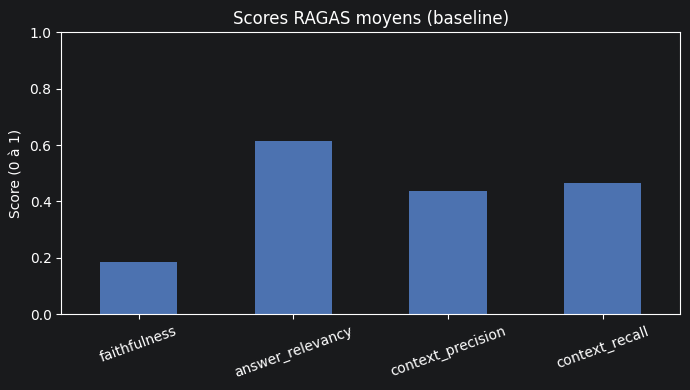

In [7]:
ax = global_scores.plot(kind="bar", color="#4C72B0", figsize=(7, 4))
ax.set_ylim(0, 1)
ax.set_title("Scores RAGAS moyens (baseline)")
ax.set_ylabel("Score (0 à 1)")
ax.set_xlabel("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Résultats par catégorie

**Interprétation :**
- une **faithfulness faible** = réponses peu ancrées dans les sources (le modèle reformule ou invente) ;
- des scores faibles sur `mixte`, `bruitee` et `hors_sujet` sont **attendus** (questions impossibles ou hors périmètre) ;
- `context_precision` / `context_recall` sont à interpréter **avec prudence** quand `reference_answer` décrit un *comportement attendu* (refus, donnée absente) plutôt que des passages sources.

In [8]:
by_cat = pd.DataFrame(summary["mean_scores_by_category"]).T[METRICS].sort_index()
by_cat

,faithfulness,answer_relevancy,context_precision,context_recall
bruitee,0.0000,0.7349,0.0000,0.25
chiffree,0.2255,0.5586,0.6833,0.40
complexe,0.5078,0.8580,0.3500,0.75
hors_sujet,0.0000,0.0000,0.0000,0.50
mixte,0.0376,0.7487,0.3084,0.00
simple,0.2738,0.8670,0.9166,1.00


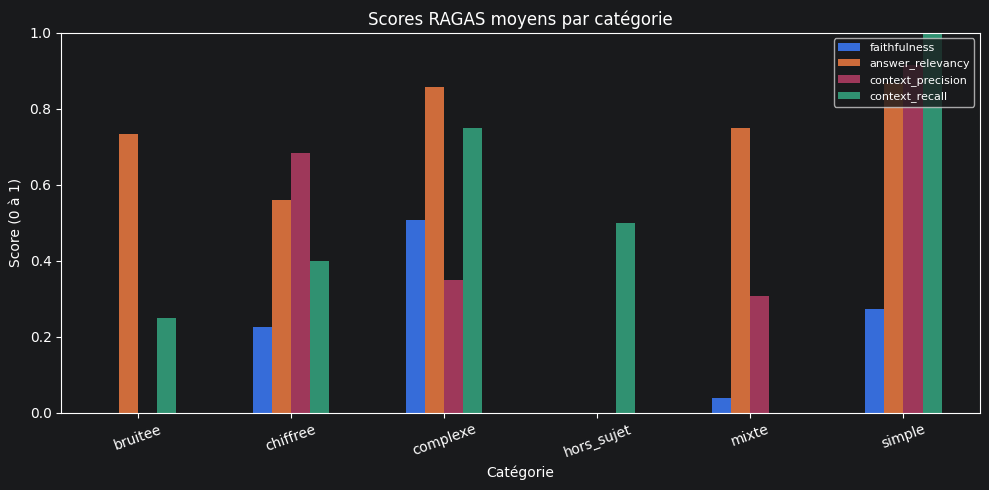

In [9]:
ax = by_cat.plot(kind="bar", figsize=(10, 5))
ax.set_ylim(0, 1)
ax.set_title("Scores RAGAS moyens par catégorie")
ax.set_ylabel("Score (0 à 1)")
ax.set_xlabel("Catégorie")
ax.legend(loc="upper right", fontsize=8)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Analyse `requires_sql_future`

On compare les scores moyens entre les questions qui **nécessiteront un calcul SQL** (`requires_sql_future = true`) et les autres. L'objectif est de montrer que les questions chiffrées / agrégées sont moins bien traitées par le RAG actuel.

In [10]:
# Moyenne des 4 métriques selon requires_sql_future (valeurs manquantes ignorées).
sql_means = results.groupby("requires_sql_future")[METRICS].mean().round(3)
sql_means

,faithfulness,answer_relevancy,context_precision,context_recall
requires_sql_future,,,,
False,0.199,0.524,0.369,0.750
True,0.168,0.716,0.517,0.143


## Exemples qualitatifs

Une question par type : simple, chiffrée, mixte et hors-sujet. Pour chacune : la référence attendue, un extrait de la réponse générée et les 4 scores RAGAS.

In [11]:
example_ids = ["E01", "E08", "E05", "E14"]  # simple, chiffree, mixte, hors_sujet
cols = ["id", "category", "question", "reference_answer", "answer", *METRICS]
examples = results[results["id"].isin(example_ids)][cols]

for _, row in examples.iterrows():
    print("=" * 90)
    print(f"[{row['id']}] catégorie : {row['category']}")
    print(f"Question  : {row['question']}")
    print(f"Référence : {row['reference_answer']}")
    print(f"Réponse   : {str(row['answer'])[:300]}...")
    print("Scores    : " + ", ".join(f"{m}={row[m]}" for m in METRICS))

[E01] catégorie : simple
Question  : Pour quelle équipe joue Nikola Jokić d'après les données de la saison ?
Référence : Denver Nuggets (DEN).
Réponse   : D'après les données fournies, **Nikola Jokić** joue pour les **Denver Nuggets (DEN)**.

*(Source : Feuille "Equipe" du fichier regular NBA.xlsx, où le code "DEN" correspond à "Denver Nuggets")*

---
**Fun Fact NBA** : Jokić, triple MVP de la saison régulière (2021, 2022, 2024), est le meneur de jeu ...
Scores    : faithfulness=0.0, answer_relevancy=0.9418, context_precision=1.0, context_recall=1.0
[E05] catégorie : mixte
Question  : Quel joueur a délivré le plus de passes décisives, et qu'est-ce que cela révèle de son rôle ?
Référence : Trae Young (ATL), valeur maximale de la colonne AST (882). C'est un meneur-créateur, principal organisateur du jeu de son équipe.
Réponse   : **🔥 Analyse NBA : Le roi des passes décisives et ce que cela révèle de son rôle 🔥**

D’après les données disponibles, le joueur ayant délivré le **plus de passe

## Conclusion

- La baseline montre une **faithfulness faible** : le prototype actuel s'appuie peu sur les sources et a tendance à reformuler ou inventer.
- Il est **insuffisant pour les questions chiffrées** (`chiffree`, `mixte`), où un calcul fiable sur les données serait nécessaire.
- Ce dataset et ces résultats constituent la **référence** pour comparer la future version améliorée par accès SQL.